# Object-Oriented Programming

In [1]:
import sys
from pathlib import Path

current = Path.cwd()
for parent in [current, *current.parents]:
    if (parent / '_config.yml').exists():
        project_root = parent
        break
else:
    project_root = Path.cwd().parent.parent

sys.path.insert(0, str(project_root))

from shared import thinkpython, diagram, jupyturtle, download

sys.modules['thinkpython'] = thinkpython
sys.modules['diagram'] = diagram
sys.modules['jupyturtle'] = jupyturtle
sys.modules['download'] = download


## Classes and Functions

At this point you know how to use functions to organize code and how to use built-in types to organize data.
The next step is **object-oriented programming**, which uses programmer-defined types to organize both code and data.

Object-oriented programming is a big topic, so we will proceed gradually.
In this chapter, we'll start with code that is not idiomatic -- that is, it is not the kind of code experienced programmers write -- but it is a good place to start.
In the next two chapters, we will use additional features to write more idiomatic code.

### Programmer-Defined Types

We have used many of Python's built-in types -- now we will define a new type.
As a first example, we'll create a type called `Time` that represents a time of day.
A programmer-defined type is also called a **class**.
A class definition looks like this:

In [2]:
class Time:
    """Represents a time of day."""

The header indicates that the new class is called `Time`.
The body is a docstring that explains what the class is for.
Defining a class creates a **class object**.

The class object is like a factory for creating objects.
To create a `Time` object, you call `Time` as if it were a function.

In [3]:
lunch = Time()

The result is a new object whose type is `__main__.Time`, where `__main__` is the name of the  module where `Time` is defined.

In [4]:
type(lunch)

__main__.Time

When you print an object, Python tells you what type it is and where it is stored in memory (the prefix `0x` means that the following number is in hexadecimal).

In [5]:
print(lunch)

Creating a new object is called **instantiation**, and the object is an **instance** of the class.

### Attributes

An object can contain variables, which are called **attributes** and pronounced with the emphasis on the first syllable, like "AT-trib-ute", rather than the second syllable, like "a-TRIB-ute".
We can create attributes using dot notation.

In [6]:
lunch.hour = 11
lunch.minute = 59
lunch.second = 1

This example creates attributes called `hour`, `minute`, and `second`, which contain the hours, minutes, and seconds of the time `11:59:01`, which is lunch time as far as I am concerned.

The following diagram shows the state of `lunch` and its attributes after these assignments. 

In [7]:
from diagram import make_frame, make_binding

d1 = dict(hour=11, minute=59, second=1)
frame = make_frame(d1, name='Time', dy=-0.3, offsetx=0.48)
binding = make_binding('lunch', frame)

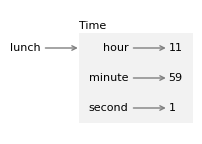

In [8]:
from diagram import diagram, adjust

width, height, x, y = [1.77, 1.24, 0.25, 0.86]
ax = diagram(width, height)
bbox = binding.draw(ax, x, y)
#adjust(x, y, bbox)

The variable `lunch` refers to a `Time` object, which contains three attributes. 
Each attribute refers to an integer.
A state diagram like this -- which shows an object and its attributes -- is called an **object diagram**.

You can read the value of an attribute using the dot operator.

In [9]:
lunch.hour

11

You can use an attribute as part of any expression.

In [10]:
total_minutes = lunch.hour * 60 + lunch.minute
total_minutes

719

And you can use the dot operator in an expression in an f-string.

In [11]:
f'{lunch.hour}:{lunch.minute}:{lunch.second}'

'11:59:1'

But notice that the previous example is not in the standard format.
To fix it, we have to print the `minute` and `second` attributes with a leading zero.
We can do that by extending the expressions in curly braces with a **format specifier**.
In the following example, the format specifiers indicate that `minute` and `second` should be displayed with at least two digits and a leading zero if needed.

In [12]:
f'{lunch.hour}:{lunch.minute:02d}:{lunch.second:02d}'

'11:59:01'

We'll use this f-string to write a function that displays the value of a `Time`object.
You can pass an object as an argument in the usual way.
For example, the following function takes a `Time` object as an argument. 

In [13]:
def print_time(time):
    s = f'{time.hour:02d}:{time.minute:02d}:{time.second:02d}'
    print(s)

When we call it, we can pass `lunch` as an argument.

In [14]:
print_time(lunch)

11:59:01


### Objects as Return Values

Functions can return objects. For example, `make_time` takes parameters called `hour`, `minute`, and `second`, stores them as attributes in a `Time` object, and returns the new object.

In [15]:
def make_time(hour, minute, second):
    time = Time()
    time.hour = hour
    time.minute = minute
    time.second = second
    return time

It might be surprising that the parameters have the same names as the attributes, but that's a common way to write a function like this.
Here's how we use `make_time` to create a `Time` object.

In [16]:
time = make_time(11, 59, 1)
print_time(time)

11:59:01


### Objects Are Mutable

Suppose you are going to a screening of a movie, like *Monty Python and the Holy Grail*, which starts at `9:20 PM` and runs for `92` minutes, which is one hour `32` minutes.
What time will the movie end?

First, we'll create a `Time` object that represents the start time.

In [17]:
start = make_time(9, 20, 0)
print_time(start)

09:20:00


To find the end time, we can modify the attributes of the `Time` object, adding the duration of the movie.

In [18]:
start.hour += 1
start.minute += 32
print_time(start)

10:52:00


The movie will be over at 10:52 PM.

Let's encapsulate this computation in a function and generalize it to take the duration of the movie in three parameters: `hours`, `minutes`, and `seconds`.

In [19]:
def increment_time(time, hours, minutes, seconds):
    time.hour += hours
    time.minute += minutes
    time.second += seconds

Here is an example that demonstrates the effect.

In [20]:
start = make_time(9, 20, 0)
increment_time(start, 1, 32, 0)
print_time(start)

10:52:00


The following stack diagram shows the state of the program just before `increment_time` modifies the object.

In [21]:
from diagram import Frame, Binding, Value, Stack

d1 = dict(hour=9, minute=20, second=0)
obj1 = make_frame(d1, name='Time', dy=-0.25, offsetx=0.78)

binding1 = make_binding('start', frame, draw_value=False, dx=0.7)
frame1 = Frame([binding1], name='__main__', loc='left', offsetx=-0.2)

binding2 = Binding(Value('time'), draw_value=False, dx=0.7, dy=0.35)
binding3 = make_binding('hours', 1)
binding4 = make_binding('minutes',32)
binding5 = make_binding('seconds', 0)
frame2 = Frame([binding2, binding3, binding4, binding5], name='increment_time', 
               loc='left', dy=-0.25, offsetx=0.08)

stack = Stack([frame1, frame2], dx=-0.3, dy=-0.5)

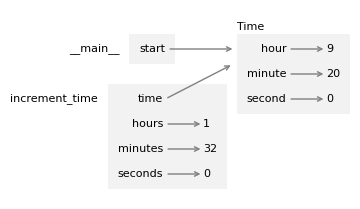

In [22]:
from diagram import Bbox

width, height, x, y = [3.4, 1.89, 1.75, 1.5]
ax = diagram(width, height)
bbox1 = stack.draw(ax, x, y)
bbox2 = obj1.draw(ax, x+0.23, y)
bbox = Bbox.union([bbox1, bbox2])
# adjust(x, y, bbox)

Inside the function, `time` is an alias for `start`, so when `time` is modified, `start` changes.

This function works, but after it runs, we're left with a variable named `start` that refers to an object that represents the *end* time, and we no longer have an object that represents the start time.
It would be better to leave `start` unchanged and make a new object to represent the end time.
We can do that by copying `start` and modifying the copy.

### Copying

The `copy` module provides a function called `copy` that can duplicate any object.
We can import it like this.

In [23]:
from copy import copy

To see how it works, let's start with a new `Time` object that represents the start time of the movie.

In [24]:
start = make_time(9, 20, 0)

And make a copy.

In [25]:
end = copy(start)

Now `start` and `end` contain the same data.

In [26]:
print_time(start)
print_time(end)

09:20:00
09:20:00


But the `is` operator confirms that they are not the same object.

In [27]:
start is end

False

Let's see what the `==` operator does.

In [28]:
start == end

False

You might expect `==` to yield `True` because the objects contain the same data.
But for programmer-defined classes, the default behavior of the `==` operator is the same as the `is` operator -- it checks identity, not equivalence.

### Pure Functions

We can use `copy` to write pure functions that don't modify their parameters.
For example, here's a function that takes a `Time` object and a duration in hours, minutes and seconds.
It makes a copy of the original object, uses `increment_time` to modify the copy, and returns it.

In [29]:
def add_time(time, hours, minutes, seconds):
    total = copy(time)
    increment_time(total, hours, minutes, seconds)
    return total

Here's how we use it.

In [30]:
end = add_time(start, 1, 32, 0)
print_time(end)

10:52:00


The return value is a new object representing the end time of the movie.
And we can confirm that `start` is unchanged.

In [31]:
print_time(start)

09:20:00


`add_time` is a **pure function** because it does not modify any of the objects passed to it as arguments and its only effect is to return a value.

Anything that can be done with impure functions can also be done with pure functions.
In fact, some programming languages only allow pure functions.
Programs that use pure functions might be less error-prone, but impure functions are sometimes convenient and can be more efficient.

In general, I suggest you write pure functions whenever it is reasonable and resort to impure functions only if there is a compelling advantage.
This approach might be called a **functional programming style**.

### Prototype and Patch

In the previous example, `increment_time` and `add_time` seem to work, but if we try another example, we'll see that they are not quite correct.

Suppose you arrive at the theater and discover that the movie starts at `9:40`, not `9:20`.
Here's what happens when we compute the updated end time.

In [32]:
start = make_time(9, 40, 0)
end = add_time(start, 1, 32, 0)
print_time(end)

10:72:00


The result is not a valid time.
The problem is that `increment_time` does not deal with cases where the number of seconds or minutes adds up to more than `60`.

Here's an improved version that checks whether `second` exceeds or equals `60` -- if so, it increments `minute` -- then checks whether `minute` exceeds or equals `60` -- if so, it increments `hour`.

In [33]:
def increment_time(time, hours, minutes, seconds):
    time.hour += hours
    time.minute += minutes
    time.second += seconds

    if time.second >= 60:
        time.second -= 60
        time.minute += 1

    if time.minute >= 60:
        time.minute -= 60
        time.hour += 1

Fixing `increment_time` also fixes `add_time`, which uses it.
So now the previous example works correctly.

In [34]:
end = add_time(start, 1, 32, 0)
print_time(end)

11:12:00


But this function is still not correct, because the arguments might be bigger than `60`.
For example, suppose we are given the run time as `92` minutes, rather than `1` hours and `32` minutes.
We might call `add_time` like this.

In [35]:
end = add_time(start, 0, 92, 0)
print_time(end)

10:72:00


The result is not a valid time.
So let's try a different approach, using the `divmod` function.
We'll make a copy of `start` and modify it by incrementing the `minute` attribute.

In [36]:
end = copy(start)
end.minute = start.minute + 92
end.minute

132

Now `minute` is `132`, which is `2` hours and `12` minutes.
We can use `divmod` to divide by `60` and return the number of whole hours and the number of minutes left over.

In [37]:
carry, end.minute = divmod(end.minute, 60)
carry, end.minute

(2, 12)

Now `minute` is correct, and we can add the hours to `hour`.

In [38]:
end.hour += carry
print_time(end)

11:12:00


The result is a valid time.
We can do the same thing with `hour` and `second`, and encapsulate the whole process in a function.

In [39]:
def increment_time(time, hours, minutes, seconds):
    time.hour += hours
    time.minute += minutes
    time.second += seconds
    
    carry, time.second = divmod(time.second, 60)
    carry, time.minute = divmod(time.minute + carry, 60)
    carry, time.hour = divmod(time.hour + carry, 24)

With this version of `increment_time`, `add_time` works correctly, even if the arguments exceed `60`.

In [40]:
end = add_time(start, 0, 90, 120)
print_time(end)

11:12:00


This section demonstrates a program development plan I call **prototype and patch**.
We started with a simple prototype that worked correctly for the first example.
Then we tested it with more difficult examples -- when we found an error, we modified the program to fix it, like putting a patch on tire with a puncture.

This approach can be effective, especially if you don't yet have a deep understanding of the problem.
But incremental corrections can generate code that is unnecessarily complicated -- since it deals with many special cases -- and unreliable -- since it is hard to know if you have
found all the errors.

## Design-First Development

An alternative plan is **design-first development**, which involves more planning before prototyping. In a design-first process, sometimes a high-level insight into the problem makes the programming much easier.

In this case, the insight is that we can think of a `Time` object as a three-digit number in base 60 -- also known as sexagesimal.
The `second` attribute is the "ones column", the `minute` attribute is the "sixties column",
and the `hour` attribute is the "thirty-six hundreds column".
When we wrote `increment_time`, we were effectively doing addition in base 60, which is why we had to carry from one column to the next.

This observation suggests another approach to the whole problem -- we can convert `Time` objects to integers and take advantage of the fact that Python knows how to do integer arithmetic.

Here is a function that converts from a `Time` to an integer.

In [41]:
def time_to_int(time):
    minutes = time.hour * 60 + time.minute
    seconds = minutes * 60 + time.second
    return seconds

The result is the number of seconds since the beginning of the day.
For example, `01:01:01` is `1` hour, `1` minute and `1` second from the beginning of the day, which is the sum of `3600` seconds, `60` seconds, and `1` second.

In [42]:
time = make_time(1, 1, 1)
print_time(time)
time_to_int(time)

01:01:01


3661

And here's a function that goes in the other direction -- converting an integer to a `Time` object -- using the `divmod` function.

In [43]:
def int_to_time(seconds):
    minute, second = divmod(seconds, 60)
    hour, minute = divmod(minute, 60)
    return make_time(hour, minute, second)

We can test it by converting the previous example back to a `Time`.

In [44]:
time = int_to_time(3661)
print_time(time)

01:01:01


Using these functions, we can write a more concise version of `add_time`.

In [45]:
def add_time(time, hours, minutes, seconds):
    duration = make_time(hours, minutes, seconds)
    seconds = time_to_int(time) + time_to_int(duration)
    return int_to_time(seconds)

The first line converts the arguments to a `Time` object called `duration`.
The second line converts `time` and `duration` to seconds and adds them.
The third line converts the sum to a `Time` object and returns it.

Here's how it works.

In [46]:
start = make_time(9, 40, 0)
end = add_time(start, 1, 32, 0)
print_time(end)

11:12:00


In some ways, converting from base 60 to base 10 and back is harder than
just dealing with times. Base conversion is more abstract; our intuition
for dealing with time values is better.

But if we have the insight to treat times as base 60 numbers -- and invest the effort to write the conversion functions `time_to_int` and `int_to_time` -- we get a program that is shorter, easier to read and debug, and more reliable.

It is also easier to add features later. For example, imagine subtracting two `Time` objects to find the duration between them.
The naive approach is to implement subtraction with borrowing.
Using the conversion functions is easier and more likely to be correct.

Ironically, sometimes making a problem harder -- or more general -- makes it easier, because there are fewer special cases and fewer opportunities for error.

### Classes and Methods

Python is an **object-oriented language** -- that is, it provides features that support object-oriented programming, which has these defining characteristics:

-   Most of the computation is expressed in terms of operations on objects.

-   Objects often represent things in the real world, and methods often correspond to the ways things in the real world interact.

-   Programs include class and method definitions.

For example, in the previous chapter we defined a `Time` class that corresponds to the way people record the time of day, and we defined functions that correspond to the kinds of things people do with times.
But there was no explicit connection between the definition of the `Time` class and the function definitions that follow.
We can make the connection explicit by rewriting a function as a **method**, which is defined inside a class definition.

In [47]:
import thinkpython, diagram, jupyturtle

### Defining Methods

In the previous chapter we defined a class named `Time` and wrote a function named `print_time` that displays a time of day.

In [48]:
class Time:
    """Represents the time of day."""

def print_time(time):
    s = f'{time.hour:02d}:{time.minute:02d}:{time.second:02d}'
    print(s)

To make `print_time` a method, all we have to do is move the function
definition inside the class definition. Notice the change in
indentation.

At the same time, we'll change the name of the parameter from `time` to `self`.
This change is not necessary, but it is conventional for the first parameter of a method to be named `self`.

In [49]:
class Time:
    """Represents the time of day."""    

    def print_time(self):
        s = f'{self.hour:02d}:{self.minute:02d}:{self.second:02d}'
        print(s)

To call this method, you have to pass a `Time` object as an argument.
Here's the function we'll use to make a `Time` object.

In [50]:
def make_time(hour, minute, second):
    time = Time()
    time.hour = hour
    time.minute = minute
    time.second = second
    return time

And here's a `Time` instance.

In [51]:
start = make_time(9, 40, 0)

Now there are two ways to call `print_time`. The first (and less common)
way is to use function syntax.

In [52]:
Time.print_time(start)

09:40:00


In this version, `Time` is the name of the class, `print_time` is the name of the method, and `start` is passed as a parameter.
The second (and more idiomatic) way is to use method syntax:

In [53]:
start.print_time()

09:40:00


In this version, `start` is the object the method is invoked on, which is called the **receiver**, based on the analogy that invoking a method is like sending a message to an object.

Regardless of the syntax, the behavior of the method is the same.
The receiver is assigned to the first parameter, so inside the method, `self` refers to the same object as `start`.

### Another Method

Here's the `time_to_int` function from the previous chapter.

In [54]:
def time_to_int(time):
    minutes = time.hour * 60 + time.minute
    seconds = minutes * 60 + time.second
    return seconds

And here's a version rewritten as a method.


In [55]:
%%add_method_to Time

    def time_to_int(self):
        minutes = self.hour * 60 + self.minute
        seconds = minutes * 60 + self.second
        return seconds

The first line uses the special command `add_method_to`, which adds a method to a previously-defined class.
This command works in a Jupyter notebook, but it is not part of Python, so it won't work in other environments.
Normally, all methods of a class are inside the class definition, so they get defined at the same time as the class.
But for this book, it is helpful to define one method at a time.

As in the previous example, the method definition is indented and the name of the parameter is `self`.
Other than that, the method is identical to the function.
Here's how we invoke it.

In [56]:
start.time_to_int()

34800

It is common to say that we "call" a function and "invoke" a method, but they mean the same thing.

### Static Methods

As another example, let's consider the `int_to_time` function.
Here's the version from the previous chapter.

In [57]:
def int_to_time(seconds):
    minute, second = divmod(seconds, 60)
    hour, minute = divmod(minute, 60)
    return make_time(hour, minute, second)

This function takes `seconds` as a parameter and returns a new `Time` object.
If we transform it into a method of the `Time` class, we have to invoke it on a `Time` object.
But if we're trying to create a new `Time` object, what are we supposed to invoke it on?

We can solve this chicken-and-egg problem using a **static method**, which is a method that does not require an instance of the class to be invoked.
Here's how we rewrite this function as a static method.

In [58]:
%%add_method_to Time

    def int_to_time(seconds):
        minute, second = divmod(seconds, 60)
        hour, minute = divmod(minute, 60)
        return make_time(hour, minute, second)

Because it is a static method, it does not have `self` as a parameter.
To invoke it, we use `Time`, which is the class object.

In [59]:
start = Time.int_to_time(34800)

The result is a new object that represents 9:40.

In [60]:
start.print_time()

09:40:00


Now that we have `Time.from_seconds`, we can use it to write `add_time` as a method.
Here's the function from the previous chapter.

In [61]:
def add_time(time, hours, minutes, seconds):
    duration = make_time(hours, minutes, seconds)
    seconds = time_to_int(time) + time_to_int(duration)
    return int_to_time(seconds)

And here's a version rewritten as a method.

In [62]:
%%add_method_to Time

    def add_time(self, hours, minutes, seconds):
        duration = make_time(hours, minutes, seconds)
        seconds = time_to_int(self) + time_to_int(duration)
        return Time.int_to_time(seconds)

`add_time` has `self` as a parameter because it is not a static method.
It is an ordinary method -- also called an **instance method**.
To invoke it, we need a `Time` instance.

In [63]:
end = start.add_time(1, 32, 0)
print_time(end)

11:12:00


### Class Methods

A **class method** is a method that receives the *class itself* as its first
argument (conventionally named `cls`) instead of an instance. Class methods
are decorated with `@classmethod` and are commonly used as **alternative
constructors** — ways to create an instance from different kinds of input.


In [ ]:
%%add_method_to Time

    @classmethod
    def from_string(cls, s):
        """Create a Time from a 'HH:MM:SS' string."""
        parts = s.split(':')
        hour, minute, second = int(parts[0]), int(parts[1]), int(parts[2])
        return cls(hour, minute, second)


In [ ]:
# Use the class method as an alternative constructor
t = Time.from_string('09:45:30')
print(t)   # 09:45:30

# Contrast: static method uses the class name; class method receives it
# as `cls`, so subclasses inherit the right constructor automatically.


### Comparing Time Objects

As one more example, let's write `is_after` as a method.
Here's the `is_after` function, which is a solution to an exercise in the previous chapter.

In [64]:
def is_after(t1, t2):
    return time_to_int(t1) > time_to_int(t2)

And here it is as a method.

In [65]:
%%add_method_to Time

    def is_after(self, other):
        return self.time_to_int() > other.time_to_int()

Because we're comparing two objects, and the first parameter is `self`, we'll call the second parameter `other`.
To use this method, we have to invoke it on one object and pass the
other as an argument.

In [66]:
end.is_after(start)

True

One nice thing about this syntax is that it almost reads like a question,
"`end` is after `start`?"

### The `__str__` Method

When you write a method, you can choose almost any name you want.
However, some names have special meanings.
For example, if an object has a method named `__str__`, Python uses that method to convert the object to a string.
For example, here is a `__str__` method for a time object.

In [67]:
%%add_method_to Time

    def __str__(self):
        s = f'{self.hour:02d}:{self.minute:02d}:{self.second:02d}'
        return s

This method is similar to `print_time`, from the previous chapter, except that it returns the string rather than printing it.

You can invoke this method in the usual way.

In [68]:
end.__str__()

'11:12:00'

But Python can also invoke it for you.
If you use the built-in function `str` to convert a `Time` object to a string, Python uses the `__str__` method in the `Time` class.

In [69]:
str(end)

'11:12:00'

And it does the same if you print a `Time` object.

In [70]:
print(end)

11:12:00


Methods like `__str__` are called **special methods**.
You can identify them because their names begin and end with two underscores.

### The `__repr__` Method

`__repr__` returns a string that ideally looks like a valid Python expression
that could recreate the object. It is used in the interactive interpreter and
by `repr()`. When `__str__` is not defined, Python falls back to `__repr__`.

| Method | Called by | Purpose |
|---|---|---|
| `__str__` | `str()`, `print()`, f-strings | Human-readable output |
| `__repr__` | `repr()`, interactive shell | Unambiguous, ideally reconstructable |


In [ ]:
%%add_method_to Time

    def __repr__(self):
        return f'Time({self.hour}, {self.minute}, {self.second})'


In [ ]:
t = Time(9, 45, 30)
print(str(t))    # 09:45:30       ← from __str__
print(repr(t))   # Time(9, 45, 30) ← from __repr__


### Properties

The `@property` decorator lets you define a method that behaves like an attribute.
This is useful when you want controlled read-only (or validated) access to a
value computed from object state, *without* changing how callers access it.


In [ ]:
%%add_method_to Time

    @property
    def total_seconds(self):
        """Total seconds since midnight (read-only)."""
        return self.hour * 3600 + self.minute * 60 + self.second


In [ ]:
t = Time(1, 30, 0)
# Access like an attribute — no parentheses needed
print(t.total_seconds)   # 5400

# Attempting to set it raises AttributeError (read-only)
try:
    t.total_seconds = 9999
except AttributeError as e:
    print(f'Error: {e}')


### The Init Method

The most special of the special methods is `__init__`, so-called because it initializes the attributes of a new object.
An `__init__` method for the `Time` class might look like this:

In [71]:
%%add_method_to Time

    def __init__(self, hour=0, minute=0, second=0):
        self.hour = hour
        self.minute = minute
        self.second = second

Now when we instantiate a `Time` object, Python invokes `__init__`, and passes along the arguments.
So we can create an object and initialize the attributes at the same time.

In [72]:
time = Time(9, 40, 0)
print(time)

09:40:00


In this example, the parameters are optional, so if you call `Time` with no arguments,
you get the default values.

In [73]:
time = Time()
print(time)

00:00:00


If you provide one argument, it overrides `hour`:

In [74]:
time = Time(9)
print(time)

09:00:00


If you provide two arguments, they override `hour` and `minute`.

In [75]:
time = Time(9, 45)
print(time)

09:45:00


And if you provide three arguments, they override all three default
values.

When I write a new class, I almost always start by writing `__init__`, which makes it easier to create objects, and `__str__`, which is useful for debugging.

## Operator Overloading

By defining other special methods, you can specify the behavior of
operators on programmer-defined types. For example, if you define a
method named `__add__` for the `Time` class, you can use the `+`
operator on Time objects.

Here is an `__add__` method.

In [76]:
%%add_method_to Time

    def __add__(self, other):
        seconds = self.time_to_int() + other.time_to_int()
        return Time.int_to_time(seconds)

We can use it like this.

In [77]:
duration = Time(1, 32)
end = start + duration
print(end)

11:12:00


There is a lot happening when we run these three lines of code:

* When we instantiate a `Time` object, the `__init__` method is invoked.

* When we use the `+` operator with a `Time` object, its `__add__` method is invoked.

* And when we print a `Time` object, its `__str__` method is invoked.

Changing the behavior of an operator so that it works with programmer-defined types is called **operator overloading**.
For every operator, like `+`, there is a corresponding special method, like `__add__`. 

## Summary

In this notebook we covered:

- **Programmer-defined types**: creating classes and working with object attributes, mutation, and copying
- **Pure functions vs. modifiers**: designing methods that avoid surprising side effects
- **Classes and methods**: `__init__`, `__str__`, `__repr__`, `@staticmethod`, `@classmethod`, `@property`
- **Operator overloading**: defining `__add__` and related methods so objects support Python operators
- **Design-first development**: prototype-and-patch, then refactor to clean class design

Next: **OOP Applied** — working with Point, Line, and Rectangle classes in a geometry library.